In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win, lev_pos_win, lev_win_multi_pos
df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/Data/surveys (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['SURVEY_DATE'])

In [2]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_pos_win(df, 15, j, i)
        output['dup_limit'] = j
        output['pos_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output8 = pd.DataFrame(records)

In [3]:
import matplotlib.pyplot as plt

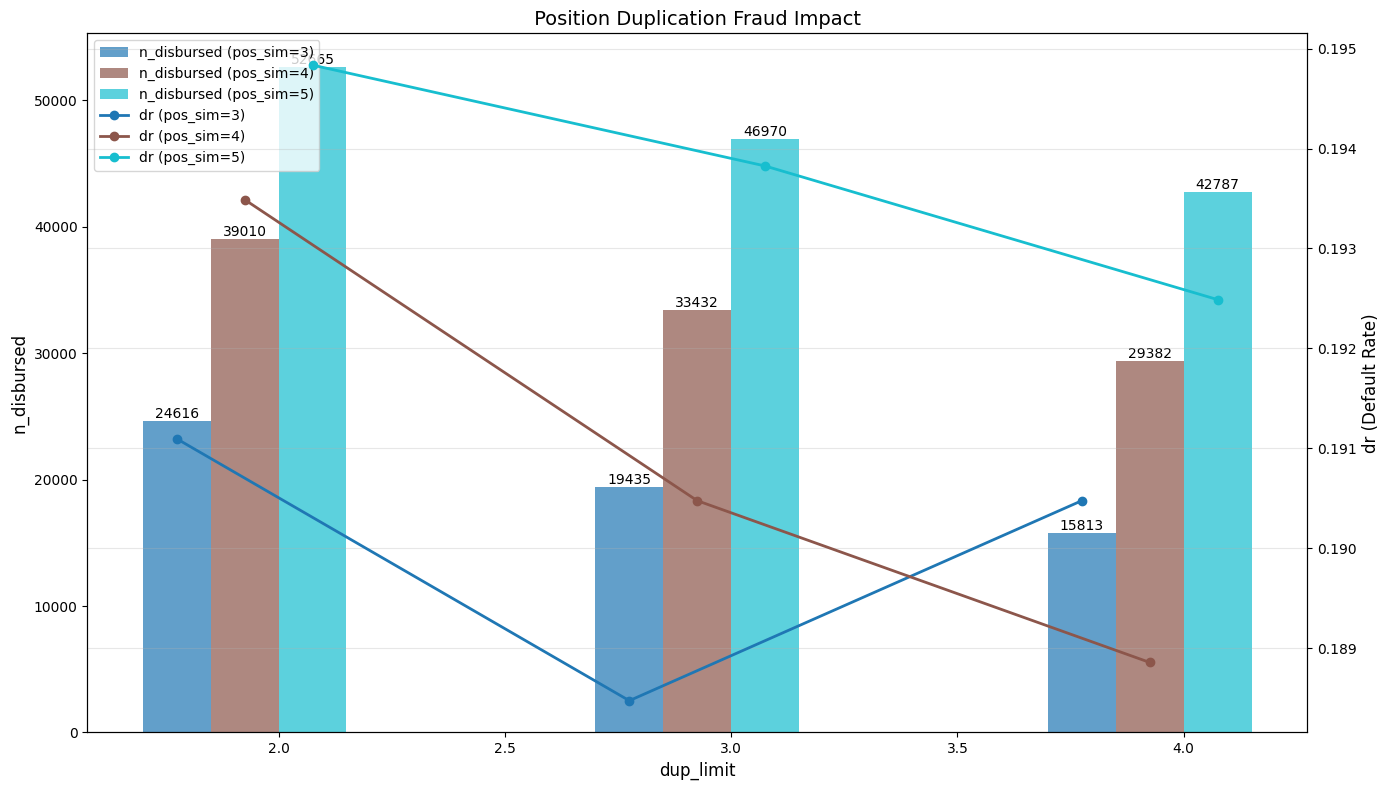

In [4]:
# Create the plot

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Define a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(output8['pos_sim'].unique())))
color_dict = {val: colors[i] for i, val in enumerate(sorted(output8['pos_sim'].unique()))}

# Plot bars and lines for each pos_sim value
for i, pos_sim in enumerate(sorted(output8['pos_sim'].unique())):
    subset = output8[output8['pos_sim'] == pos_sim]
    
    # Add slight offset to x positions for each pos_sim to avoid overlap
    width = 0.15
    offset = (i - len(output8['pos_sim'].unique())/2) * width
    
    # Plot n_disbursed as bars
    bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                  width=width, color=color_dict[pos_sim], alpha=0.7,
                  label=f'n_disbursed (pos_sim={pos_sim})')
    
    # Plot dr as lines with markers
    line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                   linestyle='-', marker='o', color=color_dict[pos_sim],
                   alpha=1.0, linewidth=2,
                   label=f'dr (pos_sim={pos_sim})')
    for bar in bars: 
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


# Set labels and title
ax1.set_xlabel('dup_limit', fontsize=12)
ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Set title
plt.title(' Position Duplication Fraud Impact ', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_win_multi_pos(df, 15, 2, j, i)
        output['dup_limit'] = i
        output['add_sim'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output10 = pd.DataFrame(records)

In [6]:
# Create the plot
def plot_multi_pos(data):
    fig, ax1 = plt.subplots(figsize=(14, 8))
    ax2 = ax1.twinx()

    # Define a colormap
    colors = plt.cm.tab10(np.linspace(0, 1, len(data['add_sim'].unique())))
    color_dict = {val: colors[i] for i, val in enumerate(sorted(data['add_sim'].unique()))}

    # Plot bars and lines for each pos_sim value
    for i, add_sim in enumerate(sorted(data['add_sim'].unique())):
        subset = data[data['add_sim'] == add_sim]
        
        # Add slight offset to x positions for each pos_sim to avoid overlap
        width = 0.15
        offset = (i - len(data['add_sim'].unique())/2) * width
        
        # Plot n_disbursed as bars
        bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                    width=width, color=color_dict[add_sim], alpha=0.7,
                    label=f'n_disbursed (add_sim={add_sim})')
        
        # Plot dr as lines with markers
        line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                    linestyle='-', marker='o', color=color_dict[add_sim],
                    alpha=1.0, linewidth=2,
                    label=f'dr (add_sim={add_sim})')
        for bar in bars: 
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


    # Set labels and title
    ax1.set_xlabel('dup_limit', fontsize=12)
    ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
    ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

    # Set title
    plt.title(' Pos_Ind_Add Duplication Fraud Impact ', fontsize=14)

    # Adjust layout and display
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_win_multi_pos(df, 15, 3, j, i)
        output['dup_limit'] = i
        output['add_sim'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output10 = pd.DataFrame(records)


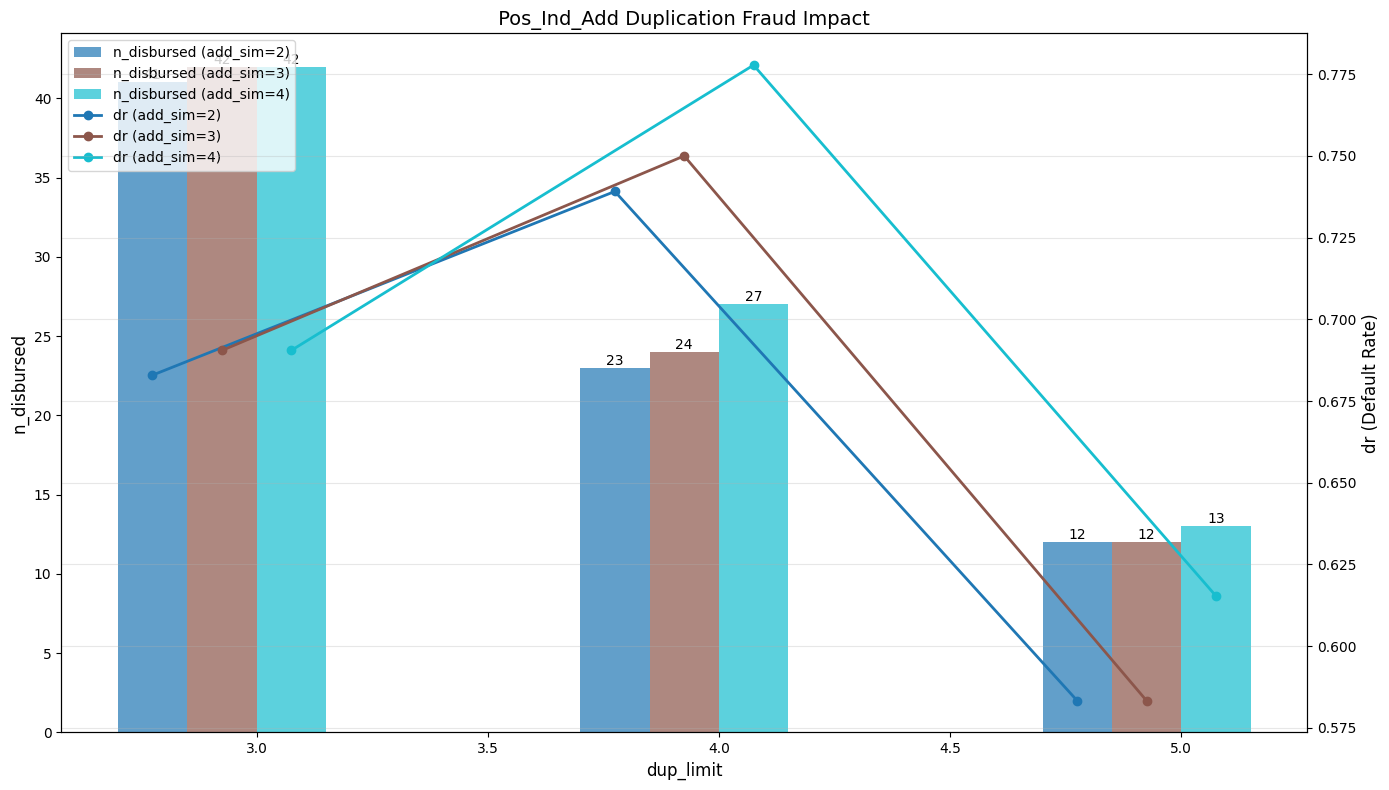

In [8]:
plot_multi_pos(output10)

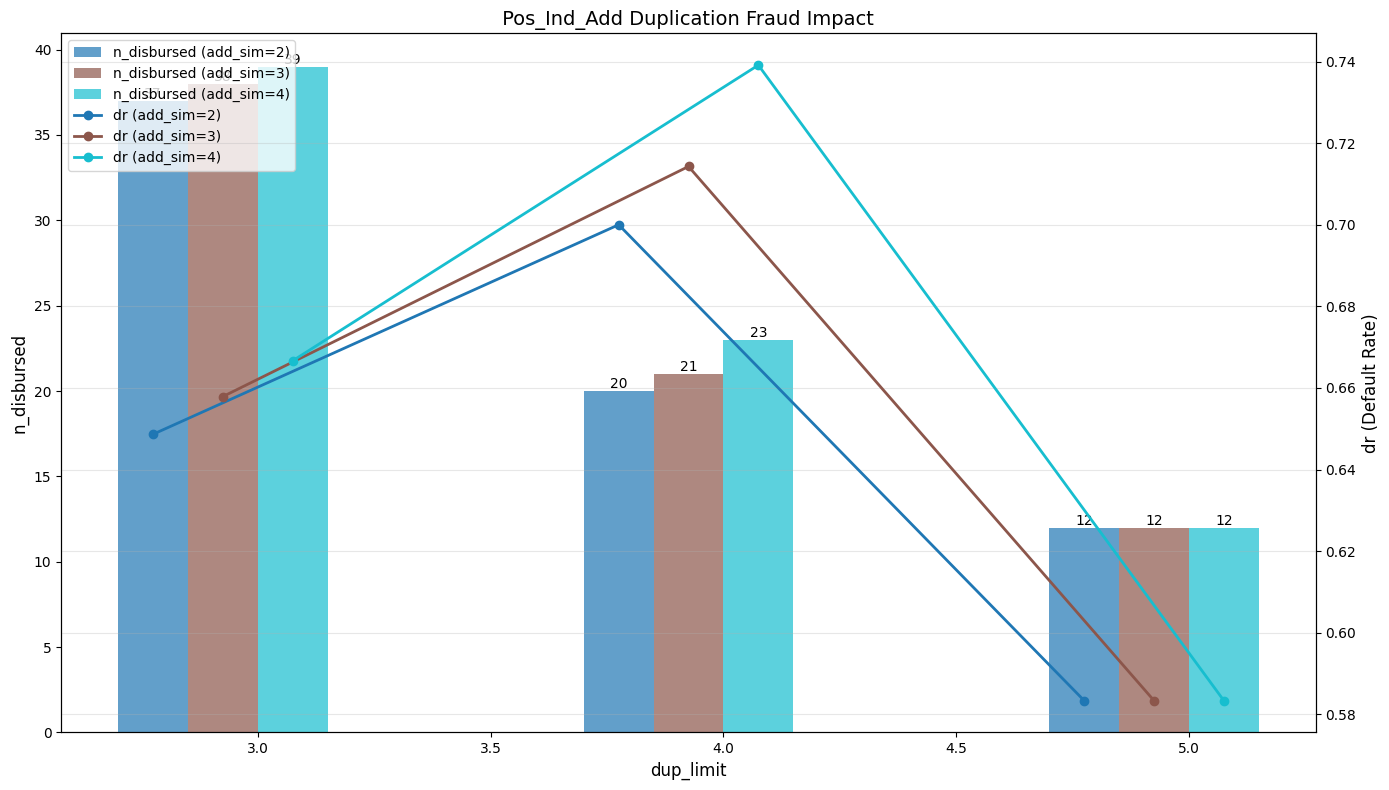

In [9]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_win_multi_pos(df, 15, 2, j, i)
        output['dup_limit'] = i
        output['add_sim'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output11 = pd.DataFrame(records)
plot_multi_pos(output11)